# Raw-evidence deliberation probes for Qwen3.5-4B

This notebook asks whether a better *single-call* response contract can recover candidate-posterior comparisons in the original noisy-source game. The game is unchanged: $N=8$, $K=3$, uniform prior, externally selected random-memoryless membership questions, and a binary symmetric reporting channel with stated reliability $r$.

The experiment was motivated by notebook 01's immediate-token failure and notebook 03's simpler capability ladder. It tests bounded generated responses that let Qwen derive its own local memberships from the raw sets, while forbidding evaluator-derived memberships, match counts, likelihoods, or posterior values in the prompt.

## Non-cheating input contract

Every prompt contains only:

- the uniform prior and domain size;
- the generic noisy-channel rule and stated $r$;
- the three raw membership sets and observed SOURCE reports;
- the two candidate names; and
- generic reasoning and output-format instructions.

The renderer never accepts the hidden truthful answers, channel coin flips, exact posterior, candidate-specific match counts, or any evaluator-computed summary. Exact targets are joined only after generation for scoring. The structured likelihood variants state the generic channel rule—an agreement contributes factor $r$ and a disagreement contributes $1-r$—but Qwen must derive every membership and comparison itself.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'raw_reasoning_probe'
MINIMAL_DIR = REPO_ROOT / 'artifacts' / 'minimal_noisy_source'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repository: {REPO_ROOT}')


Repository: /workspace/MATS


## Development protocol and resource budget

Four bounded single-call variants were evaluated on repeat 0 only (56 decisions: eight secrets by seven reliabilities), using the canonical candidate orientation. This is a development-only screen:

1. `silent_no_thinking`: one final line, no visible audit.
2. `structured_no_thinking`: a four-line membership audit with no explicit likelihood reminder.
3. `structured_likelihood_no_thinking`: the same audit plus the generic channel factor rule.
4. `atomic_likelihood_no_thinking`: six explicit ALPHA/BETA membership blanks plus the generic factor rule.

All generations are greedy. A variant would advance only if it showed strong accuracy, predicted both candidate directions, and remained worth testing under operand reversal. Repeats 8–11 (validation) and 12–15 (test) were not spent on a failed variant. Thinking-enabled smoke probes were excluded from the grid because even 2,048 new tokens did not reliably reach a final field; that is a response-efficiency failure, not evidence of a correct decision.

In [2]:
RUN_PILOT = os.environ.get('RUN_RAW_REASONING_PILOT', '0') == '1'
if RUN_PILOT:
    command = [
        sys.executable,
        str(REPO_ROOT / 'scripts' / 'run_raw_reasoning_probe.py'),
        '--output', str(ARTIFACT_DIR / 'pilot_results.jsonl'),
        '--manifest', str(ARTIFACT_DIR / 'pilot_manifest.json'),
        '--repeats', '0',
        '--variants', (
            'silent_no_thinking,structured_no_thinking,'
            'structured_likelihood_no_thinking,atomic_likelihood_no_thinking'
        ),
        '--orientations', 'forward',
        '--batch-size', os.environ.get('RAW_REASONING_BATCH_SIZE', '12'),
        '--overwrite',
    ]
    subprocess.run(command, cwd=REPO_ROOT, check=True)
else:
    print('Using saved pilot artifacts. Set RUN_RAW_REASONING_PILOT=1 to rerun inference.')


Using saved pilot artifacts. Set RUN_RAW_REASONING_PILOT=1 to rerun inference.


In [3]:
def read_jsonl(path: Path) -> list[dict[str, object]]:
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]


pilot_rows = read_jsonl(ARTIFACT_DIR / 'pilot_results.jsonl')
baseline_rows = read_jsonl(MINIMAL_DIR / 'qwen_counterbalanced_results.jsonl')
symmetry_rows = read_jsonl(MINIMAL_DIR / 'honest_symmetry_results.jsonl')
self_compute_rows = read_jsonl(MINIMAL_DIR / 'honest_qwen_self_computation_results.jsonl')
v4_development_rows = read_jsonl(ARTIFACT_DIR / 'self_computation_v4_development_results.jsonl')
v4_replication_rows = read_jsonl(ARTIFACT_DIR / 'self_computation_v4_replication_results.jsonl')
print(
    f'Loaded {len(pilot_rows)} pilot generations, {len(baseline_rows)} baseline decisions, '
    f'{len(symmetry_rows)} symmetry decisions, {len(self_compute_rows)} original self-computation decisions, '
    f'and {len(v4_replication_rows)} fresh V4 replication decisions.'
)


Loaded 224 pilot generations, 3584 baseline decisions, 1344 symmetry decisions, 1344 original self-computation decisions, and 224 fresh V4 replication decisions.


In [4]:
def mean(values: list[float]) -> float:
    return sum(values) / len(values)


pilot_by_variant: dict[str, list[dict[str, object]]] = defaultdict(list)
for row in pilot_rows:
    pilot_by_variant[str(row['variant'])].append(row)

pilot_summary = {}
print('variant\tn\taccuracy\tparse_rate\tpredicted_candidates')
for variant, rows in sorted(pilot_by_variant.items()):
    predictions: dict[str, int] = defaultdict(int)
    for row in rows:
        predictions[str(row['predicted_absolute'])] += 1
    summary = {
        'n': len(rows),
        'accuracy': mean([float(bool(row['correct'])) for row in rows]),
        'parse_rate': mean([float(bool(row['parse_success'])) for row in rows]),
        'predictions': dict(predictions),
    }
    pilot_summary[variant] = summary
    print(
        f"{variant}\t{summary['n']}\t{summary['accuracy']:.4f}\t"
        f"{summary['parse_rate']:.4f}\t{summary['predictions']}"
    )


variant	n	accuracy	parse_rate	predicted_candidates
atomic_likelihood_no_thinking	56	0.5179	1.0000	{'tie': 41, '2': 15}
silent_no_thinking	56	0.4286	1.0000	{'2': 56}
structured_likelihood_no_thinking	56	0.4107	1.0000	{'tie': 51, '2': 5}
structured_no_thinking	56	0.3571	1.0000	{'tie': 55, '2': 1}


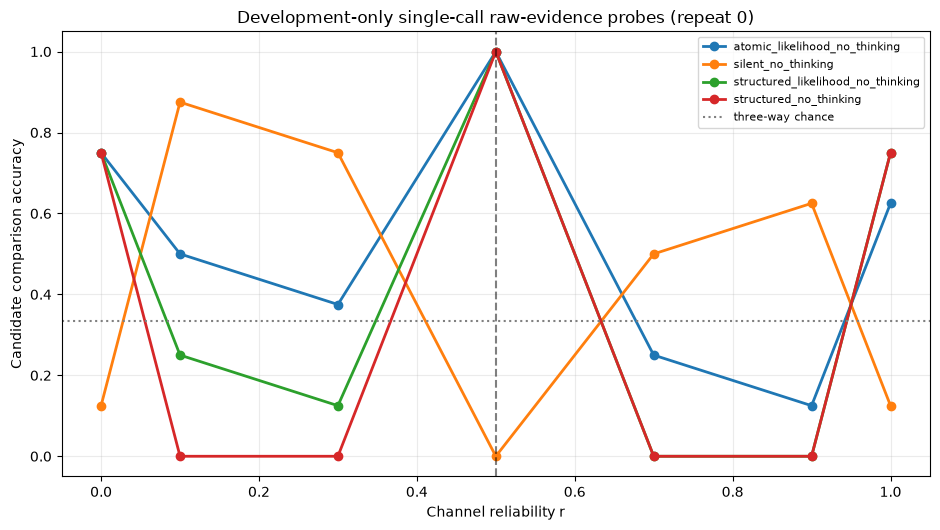

Saved /workspace/MATS/artifacts/raw_reasoning_probe/pilot_accuracy.png


In [5]:
reliabilities = sorted({float(row['reliability']) for row in pilot_rows})
fig, axis = plt.subplots(figsize=(9.5, 5.4))
for variant, rows in sorted(pilot_by_variant.items()):
    values = []
    for reliability in reliabilities:
        subset = [row for row in rows if float(row['reliability']) == reliability]
        values.append(mean([float(bool(row['correct'])) for row in subset]))
    axis.plot(reliabilities, values, marker='o', linewidth=2, label=variant)
axis.axhline(1 / 3, color='gray', linestyle=':', label='three-way chance')
axis.axvline(0.5, color='black', linestyle='--', alpha=0.5)
axis.set(xlabel='Channel reliability r', ylabel='Candidate comparison accuracy', ylim=(-0.05, 1.05))
axis.set_title('Development-only single-call raw-evidence probes (repeat 0)')
axis.grid(alpha=0.25)
axis.legend(fontsize=8)
fig.tight_layout()
pilot_figure = ARTIFACT_DIR / 'pilot_accuracy.png'
fig.savefig(pilot_figure, dpi=180)
plt.show()
print(f'Saved {pilot_figure}')


## Development gate: no single-call variant advances

All four variants parse, so answer-format compliance is not the issue. The best variant, the six-line atomic audit, reaches only 51.8% and never predicts the second candidate; the silent probe always predicts the first candidate. Adding the generic likelihood rule shifts the collapsed output toward `TIE` without restoring directional comparison. This repeats notebook 01's mechanistic signature: changing the response scaffold relocates a late output prior but does not create an equivariant posterior comparator.

Because no variant passes the development gate, validation and held-out test repeats remain untouched. This is stronger evidence than choosing the least-bad prompt and over-interpreting a test score.

### Why accuracy need not decrease at exactly r=0.5

At $r=0.5$, every candidate has the same likelihood for every report history. The exact three-way target is therefore always `TIE`, so classification accuracy can increase even though the observations carry zero information. The expected approach to maximal channel entropy is visible in shrinking posterior *effect size* or confidence, not necessarily in discrete argmax accuracy. This distinction is important when interpreting the reliability curve.

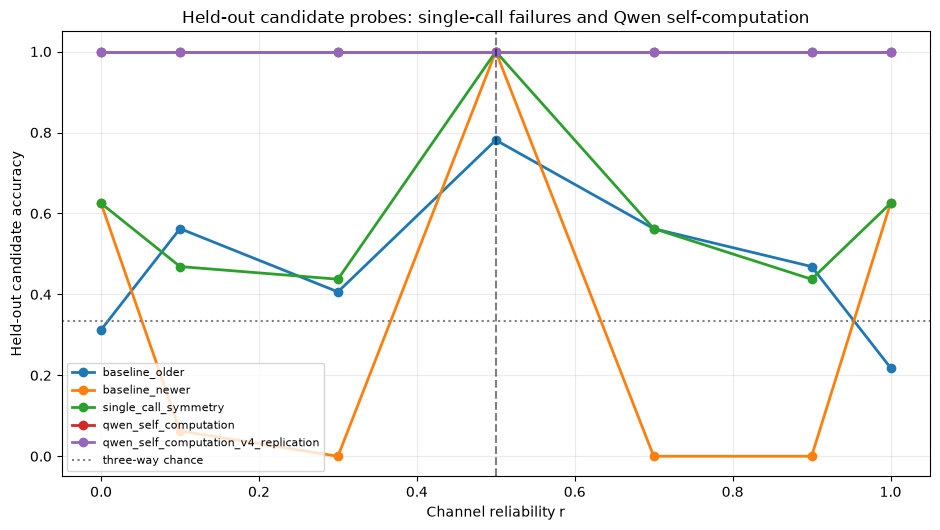

method	n	heldout_accuracy
baseline_older	224	0.4732
baseline_newer	224	0.3304
single_call_symmetry	224	0.5938
qwen_self_computation	224	1.0000
qwen_self_computation_v4_replication	224	1.0000
Saved /workspace/MATS/artifacts/raw_reasoning_probe/heldout_candidate_comparison.png


In [6]:
test_repeats = {12, 13, 14, 15}
method_rows: dict[str, list[dict[str, object]]] = defaultdict(list)
for row in baseline_rows:
    if row['probe_kind'] == 'candidate' and int(row['repeat']) in test_repeats:
        method_rows[f"baseline_{row['prompt_variant']}"].append(
            {'reliability': float(row['reliability']), 'correct': bool(row['counterbalanced_correct'])}
        )
for row in symmetry_rows:
    if row['split'] == 'test' and row['probe_kind'] == 'candidate':
        method_rows['single_call_symmetry'].append(
            {'reliability': float(row['reliability']), 'correct': bool(row['correct'])}
        )
for row in self_compute_rows:
    if row['split'] == 'test' and row['probe_kind'] == 'candidate':
        method_rows['qwen_self_computation'].append(
            {'reliability': float(row['reliability']), 'correct': bool(row['correct'])}
        )
for row in v4_replication_rows:
    method_rows['qwen_self_computation_v4_replication'].append(
        {'reliability': float(row['reliability']), 'correct': bool(row['correct'])}
    )

heldout_summary = {}
fig, axis = plt.subplots(figsize=(9.5, 5.4))
for method, rows in method_rows.items():
    values = []
    for reliability in reliabilities:
        subset = [row for row in rows if float(row['reliability']) == reliability]
        values.append(mean([float(bool(row['correct'])) for row in subset]))
    heldout_summary[method] = {
        'n': len(rows),
        'accuracy': mean([float(bool(row['correct'])) for row in rows]),
        'by_reliability': dict(zip(map(str, reliabilities), values)),
    }
    axis.plot(reliabilities, values, marker='o', linewidth=2, label=method)
axis.axhline(1 / 3, color='gray', linestyle=':', label='three-way chance')
axis.axvline(0.5, color='black', linestyle='--', alpha=0.5)
axis.set(xlabel='Channel reliability r', ylabel='Held-out candidate accuracy', ylim=(-0.05, 1.05))
axis.set_title('Held-out candidate probes: single-call failures and Qwen self-computation')
axis.grid(alpha=0.25)
axis.legend(fontsize=8)
fig.tight_layout()
heldout_figure = ARTIFACT_DIR / 'heldout_candidate_comparison.png'
fig.savefig(heldout_figure, dpi=180)
plt.show()
print('method\tn\theldout_accuracy')
for method, summary in heldout_summary.items():
    print(f"{method}\t{summary['n']}\t{summary['accuracy']:.4f}")
print(f'Saved {heldout_figure}')


## The validated probe update: Qwen-generated self-computation

The positive control is notebook 01's frozen multi-call candidate scaffold. It starts from the same raw sets and reports, asks Qwen atomic literal membership questions, asks Qwen to compare its own generated truth/report pairs, and asks Qwen to make the final reliability-aware comparison. The evaluator only formats subquestions, routes text, parses terminal fields, and scores; it never supplies a membership, count, likelihood, posterior, target-derived summary, or correction. Wrong model-generated intermediates are retained.

The new executable runner freezes its prompt and 320-token final-stage cap after 224/224 development decisions on repeats 0–3, then independently reaches 224/224 on previously unused repeats 4–7, with 100% parsing and 100% atomic-membership audit at every reliability. The earlier saved artifact also reports 100% on its original development, validation, and test splits. This is therefore the validated prompt/probe update for candidate selection. It must be described as a **multi-call inference scaffold**, not as evidence that a single prompt computes the posterior. If the scientific estimand requires one user message and one model continuation, the honest result is the negative single-call finding above.

In [7]:
notebook_manifest = {
    'experiment': 'raw_evidence_deliberation_probe',
    'model': 'Qwen3.5-4B',
    'game': {'n': 8, 'k': 3, 'policy': 'random_memoryless'},
    'input_contract': {
        'visible': 'uniform prior, reliability rule, raw membership sets/reports, candidates, generic instructions',
        'forbidden': 'evaluator-derived memberships, counts, likelihoods, posteriors, or corrections',
    },
    'single_call_pilot': {
        'repeats': [0],
        'records': len(pilot_rows),
        'summary': pilot_summary,
        'decision': 'no variant advanced to validation or test',
    },
    'heldout_candidate_comparison': heldout_summary,
    'v4_reproduction': {
        'development_repeats': [0, 1, 2, 3],
        'replication_repeats': [4, 5, 6, 7],
        'development_accuracy': mean([float(bool(row['correct'])) for row in v4_development_rows]),
        'replication_accuracy': mean([float(bool(row['correct'])) for row in v4_replication_rows]),
        'replication_parse_rate': mean([float(bool(row['parsed'])) for row in v4_replication_rows]),
        'source_artifact': 'artifacts/raw_reasoning_probe/self_computation_v4_replication_results.jsonl',
    },
    'selected_probe': {
        'name': 'qwen_self_computation',
        'scope': 'multi-call Qwen-generated inference scaffold',
        'selection_repeats': [0, 1, 2, 3],
        'replication_repeats': [4, 5, 6, 7],
        'source_artifact': 'artifacts/raw_reasoning_probe/self_computation_v4_replication_results.jsonl',
    },
}
manifest_path = ARTIFACT_DIR / 'notebook_manifest.json'
manifest_path.write_text(json.dumps(notebook_manifest, indent=2) + '\n', encoding='utf-8')
print(f'Saved {manifest_path}')


Saved /workspace/MATS/artifacts/raw_reasoning_probe/notebook_manifest.json


## Conclusion

A better single-call format is not enough for Qwen3.5-4B on this task. The new structured probes improve parseability and expose the intermediate binding error, but they do not produce a directionally complete posterior comparator. The scientifically supported update is to treat the multi-call, Qwen-generated self-computation probe as the high-accuracy candidate method and retain the single-call probe as a mechanistic negative control. No result here is obtained by placing evaluator-computed sufficient statistics or probabilities in the model prompt.